In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        50   (2094, 964)   float32   


In [3]:
image_cut = image[65:165, 0:1890]
image_error_cut = image_error[65:165, 0:1890]

Text(0.5, 0, 'wavelength')

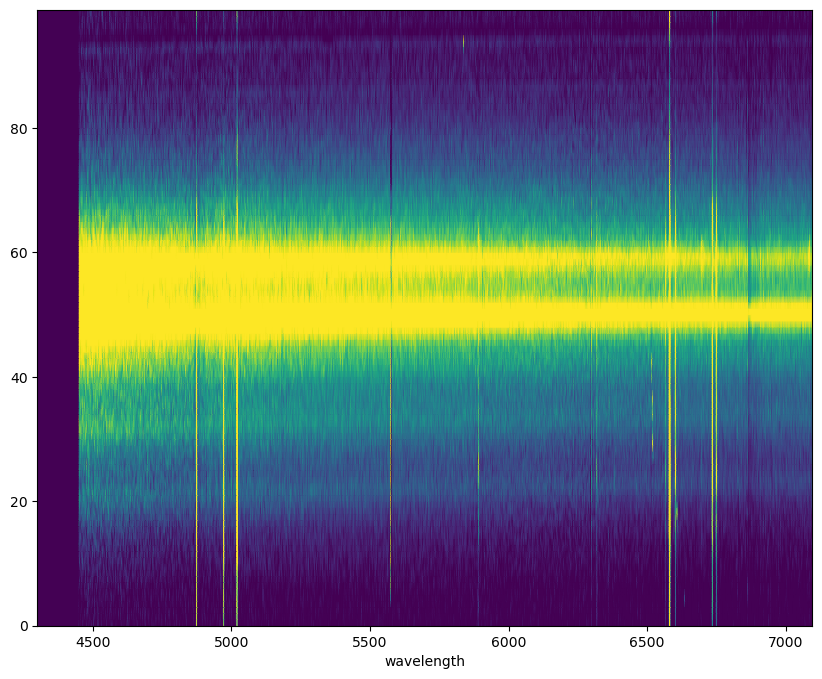

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.00323
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/PSF/Real_seeing_NGC5058.txt")
sigmas = seeing / 2.35
n_component = 5
print(sigmas)

[1.34489793 1.48843306 1.34129394 1.31750216 1.49850846 1.35106383]


In [7]:
l_HA

6584.198490000001

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        50   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

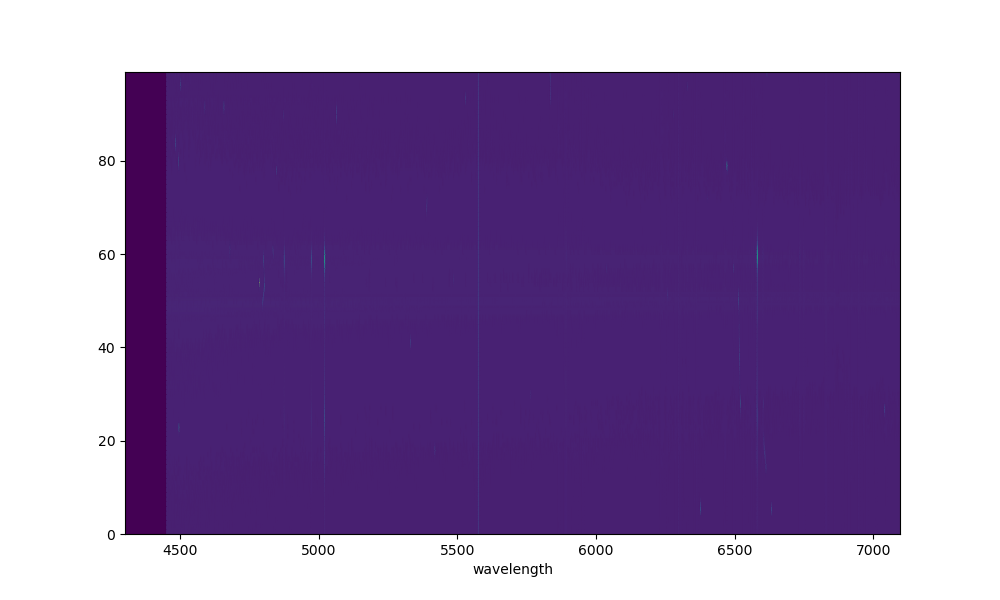

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[65:165, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

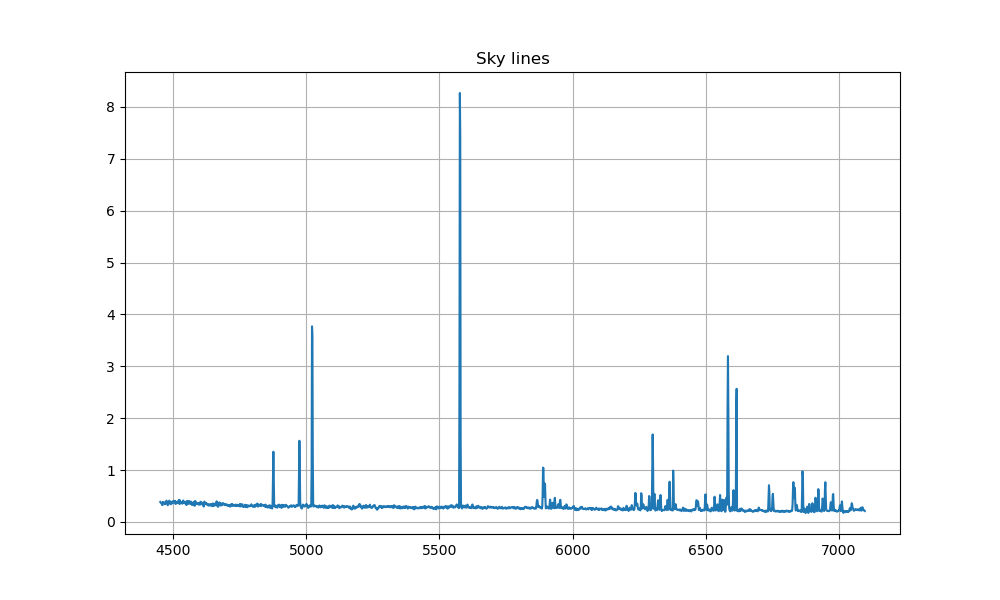

In [9]:
mask_sky = (y > 6)*(y < 16)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

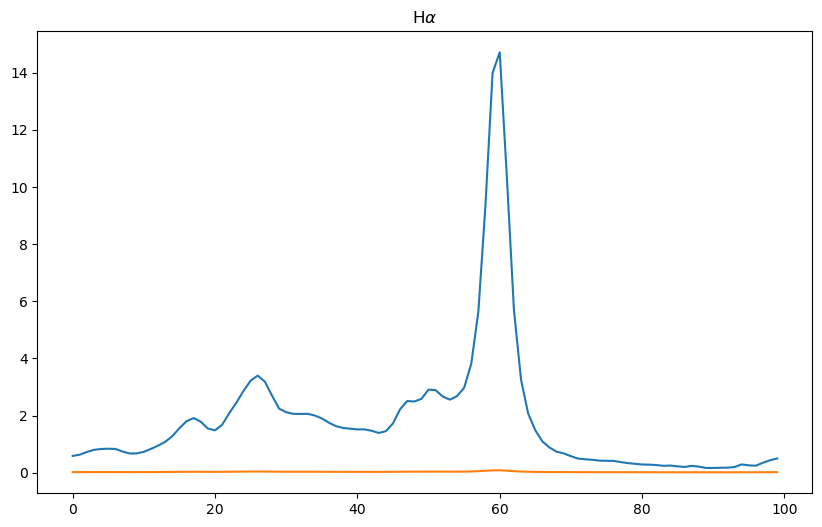

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [6]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 50),
    (0.1, 10),
    (13, 20),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (20, 28),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (30, 38),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (56, 64)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 267308.1904750228
differential_evolution step 2: f(x)= 97720.01070023759
differential_evolution step 3: f(x)= 5198.390075020344
differential_evolution step 4: f(x)= 5198.390075020344
differential_evolution step 5: f(x)= 5198.390075020344
differential_evolution step 6: f(x)= 5198.390075020344
differential_evolution step 7: f(x)= 5198.390075020344
differential_evolution step 8: f(x)= 5198.390075020344
differential_evolution step 9: f(x)= 5198.390075020344
differential_evolution step 10: f(x)= 5198.390075020344
differential_evolution step 11: f(x)= 5198.390075020344
differential_evolution step 12: f(x)= 5198.390075020344
differential_evolution step 13: f(x)= 5198.390075020344
differential_evolution step 14: f(x)= 5198.390075020344
differential_evolution step 15: f(x)= 3230.3505494172423
differential_evolution step 16: f(x)= 3230.3505494172423
differential_evolution step 17: f(x)= 2303.168800969409
differential_evolution step 18: f(x)= 2303.168800969409

Sérsic 1: I_e=0.0493, r_e=49.8953, n=1.9799, x_0=16.5389
Sérsic 2: I_e=0.6928, r_e=3.0304, n=0.9030, x_0=25.6716
Sérsic 3: I_e=0.1112, r_e=49.7637, n=1.5145, x_0=32.7145
Sérsic 4: I_e=0.2121, r_e=22.9516, n=1.5071, x_0=50.5445
Sérsic 5: I_e=1.2286, r_e=3.6371, n=2.3979, x_0=59.6129


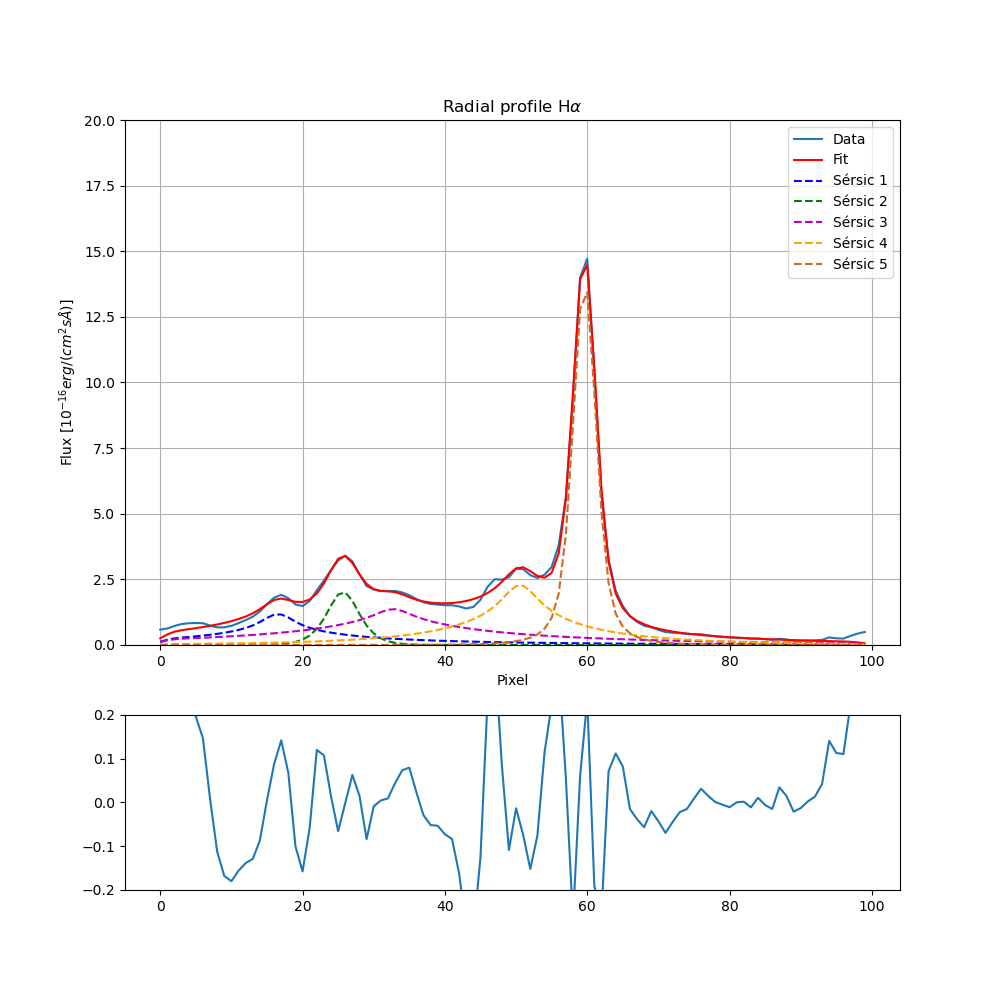

In [13]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [14]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0133, r_e=49.8966, n=2.8888, x_0=16.6609
Sérsic 2: I_e=0.6733, r_e=2.9361, n=0.9005, x_0=25.5921
Sérsic 3: I_e=0.2375, r_e=49.7753, n=1.1686, x_0=32.4415
Sérsic 4: I_e=0.0957, r_e=22.6490, n=2.0918, x_0=50.2634
Sérsic 5: I_e=1.8828, r_e=3.2414, n=1.8579, x_0=59.5372
[3.78995724e-01 1.34351673e+03 2.09854240e+01 1.18190022e-02
 6.53475145e-01 1.92631329e+00 7.50476699e-01 2.91148608e-01
 3.82753987e-01 2.37079030e+01 5.23048332e-01 2.38874354e+00
 3.87114740e-01 1.07248156e+02 2.60259635e+00 2.77973861e-01
 1.05113687e+00 1.12109573e+00 5.18342926e-01 6.42739363e-02]
3.7033031332494217


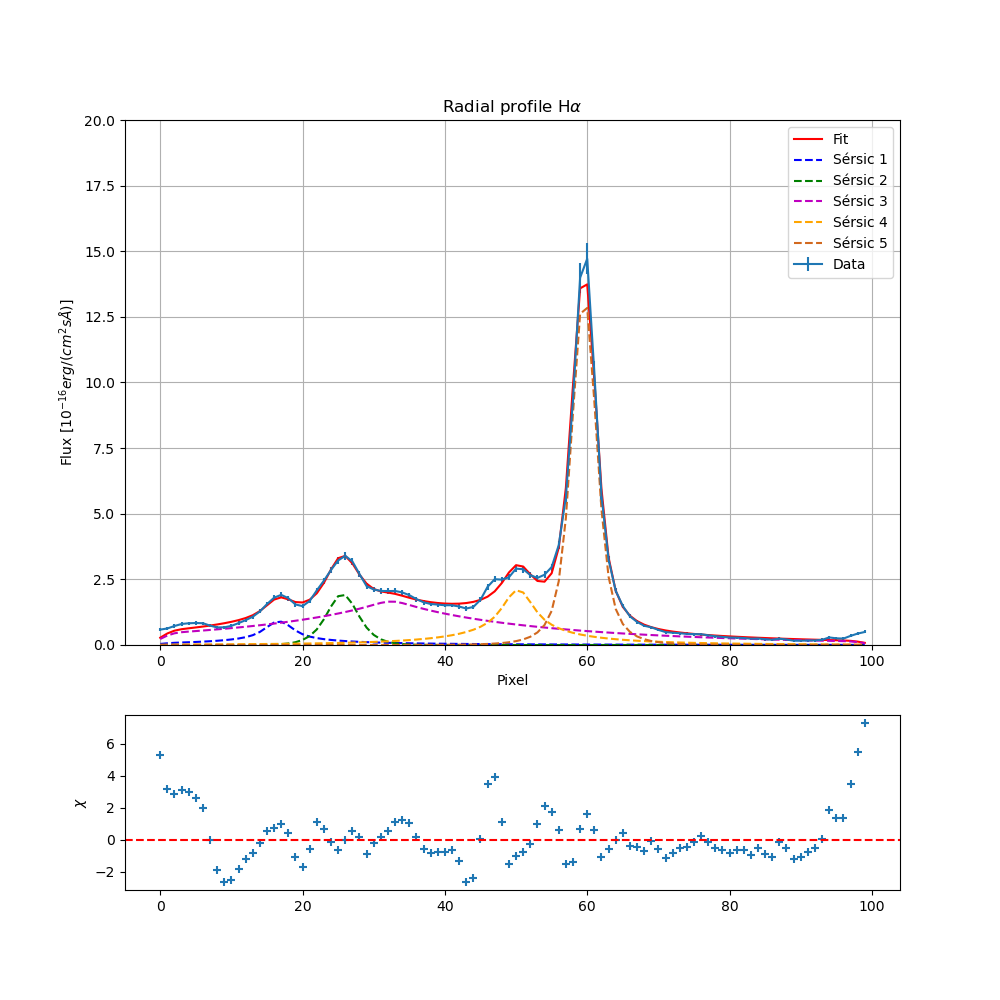

In [15]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [40]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 0.15),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2)
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

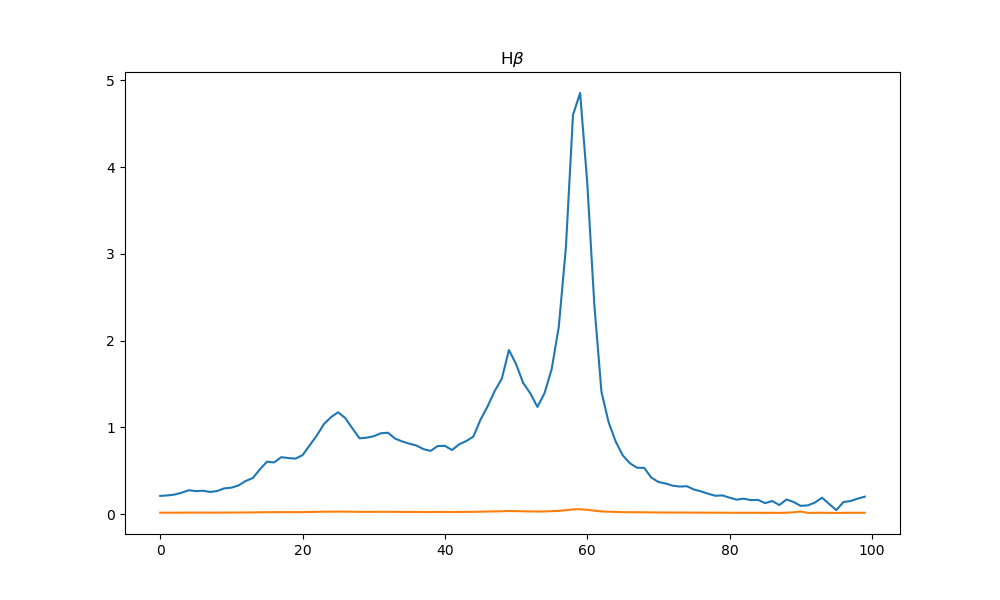

In [41]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [42]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 31878.671296628087
differential_evolution step 2: f(x)= 31878.671296628087
differential_evolution step 3: f(x)= 31878.671296628087
differential_evolution step 4: f(x)= 21409.768909369453
differential_evolution step 5: f(x)= 11213.319264209473
differential_evolution step 6: f(x)= 11213.319264209473
differential_evolution step 7: f(x)= 3784.6841732069424
differential_evolution step 8: f(x)= 2579.5353263535667
differential_evolution step 9: f(x)= 2579.5353263535667
differential_evolution step 10: f(x)= 2579.5353263535667
differential_evolution step 11: f(x)= 2579.5353263535667
differential_evolution step 12: f(x)= 2579.5353263535667
differential_evolution step 13: f(x)= 2579.5353263535667
differential_evolution step 14: f(x)= 2579.5353263535667
differential_evolution step 15: f(x)= 2579.5353263535667
differential_evolution step 16: f(x)= 1191.5098815395345
differential_evolution step 17: f(x)= 418.6361205078888
differential_evolution step 18: f(x)= 418

Sérsic 1: I_e=0.0371, r_e=1.1560, n=2.3101, x_0=15.9003
Sérsic 2: I_e=0.1183, r_e=6.9535, n=1.1424, x_0=24.5968
Sérsic 3: I_e=0.1098, r_e=49.8738, n=0.9933, x_0=32.1465
Sérsic 4: I_e=0.0342, r_e=47.7125, n=2.4446, x_0=49.2932
Sérsic 5: I_e=0.1789, r_e=6.6418, n=3.0021, x_0=58.7464


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_11664\2443474052.py:68: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


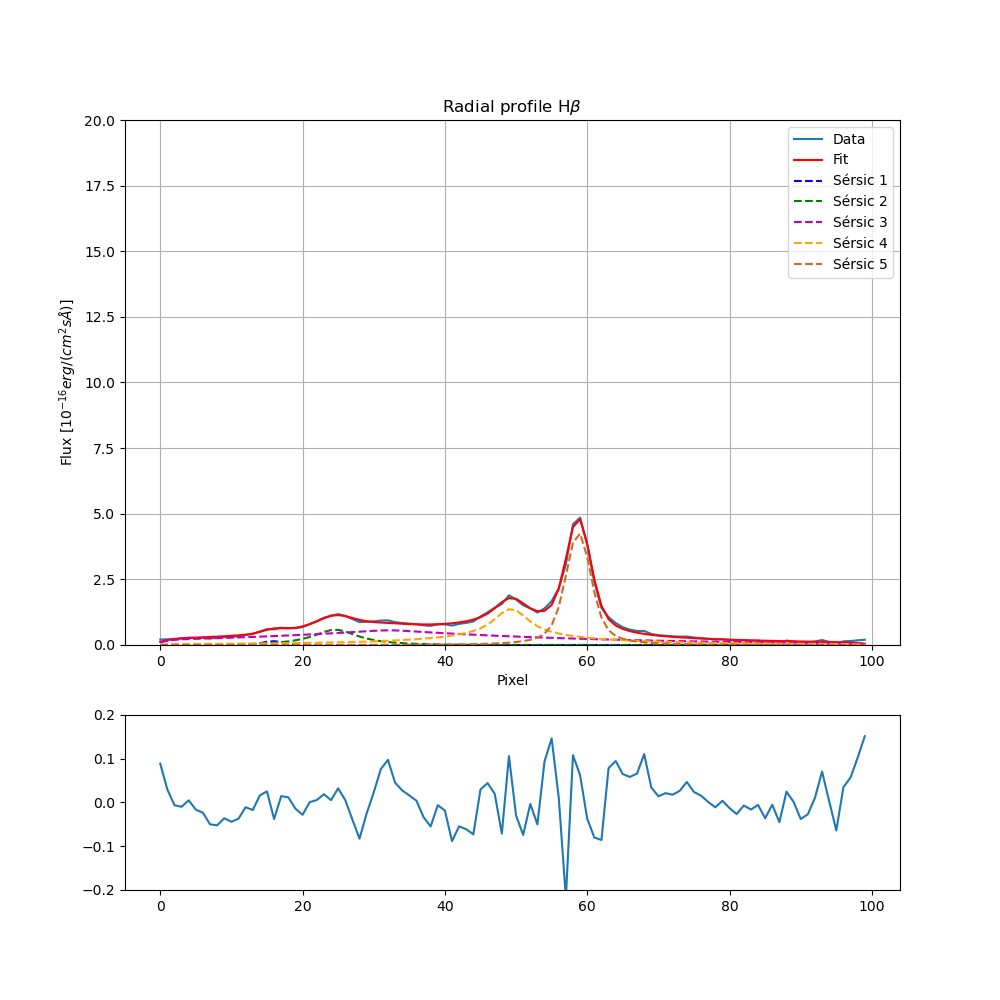

In [43]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [44]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0402, r_e=1.1487, n=2.3111, x_0=15.8954
Sérsic 2: I_e=0.1191, r_e=6.9264, n=1.1504, x_0=24.5863
Sérsic 3: I_e=0.1037, r_e=49.8743, n=1.0260, x_0=32.1551
Sérsic 4: I_e=0.0345, r_e=47.7429, n=2.4108, x_0=49.2671
Sérsic 5: I_e=0.1796, r_e=7.2886, n=2.8725, x_0=58.7464
[2.95615969e+00 4.42117026e+01 7.70633390e+01 6.02574259e-01
 3.17266387e-01 2.21452083e+01 1.78323483e+00 3.60669222e-01
 5.00309569e-02 2.81731960e+01 3.37899259e-01 2.81580533e+00
 6.97794100e-02 1.07408696e+02 1.29794373e+00 1.53116658e-01
 3.82029566e-01 9.50952358e+00 3.24978132e+00 1.70746746e-03]
0.7179976944631016


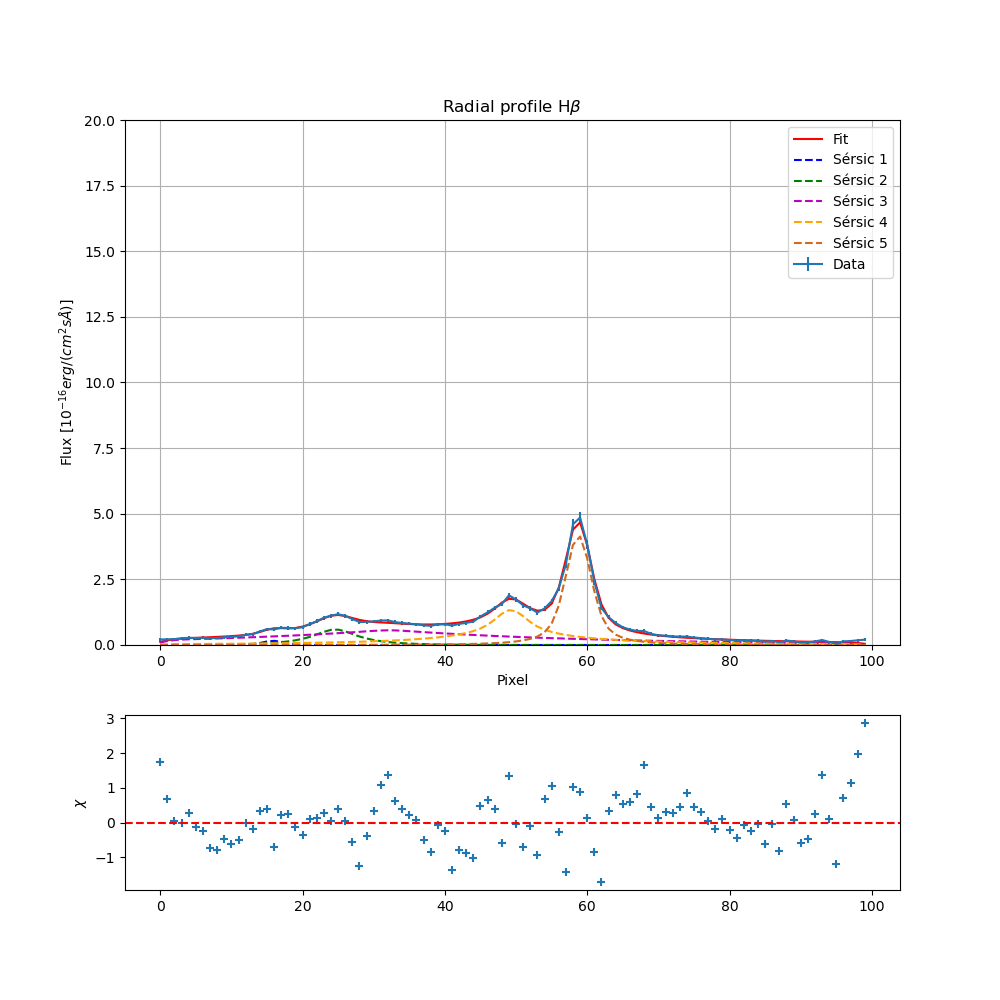

In [45]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

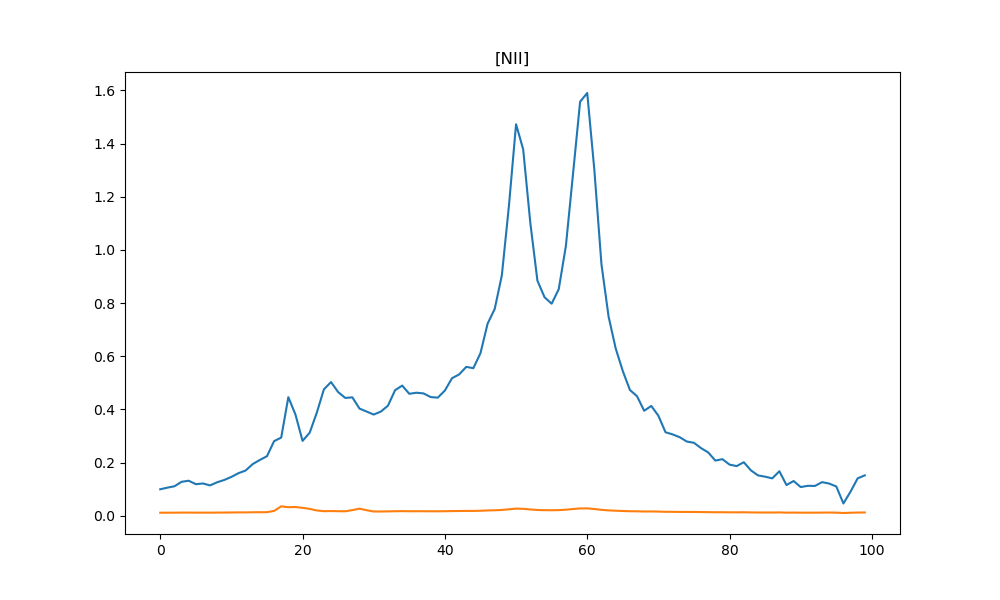

In [46]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [48]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 112263.98552778161
differential_evolution step 2: f(x)= 19773.43825682068
differential_evolution step 3: f(x)= 15250.954793461295
differential_evolution step 4: f(x)= 7100.76470807018
differential_evolution step 5: f(x)= 7100.76470807018
differential_evolution step 6: f(x)= 7100.76470807018
differential_evolution step 7: f(x)= 5226.610022693805
differential_evolution step 8: f(x)= 5226.610022693805
differential_evolution step 9: f(x)= 5226.610022693805
differential_evolution step 10: f(x)= 1159.3095351214904
differential_evolution step 11: f(x)= 1159.3095351214904
differential_evolution step 12: f(x)= 1159.3095351214904
differential_evolution step 13: f(x)= 1159.3095351214904
differential_evolution step 14: f(x)= 1159.3095351214904
differential_evolution step 15: f(x)= 1159.3095351214904
differential_evolution step 16: f(x)= 1159.3095351214904
differential_evolution step 17: f(x)= 1159.3095351214904
differential_evolution step 18: f(x)= 1159.3095351

Sérsic 1: I_e=0.2164, r_e=0.2756, n=1.4383, x_0=18.0614
Sérsic 2: I_e=0.1396, r_e=1.3544, n=0.5242, x_0=24.1067
Sérsic 3: I_e=0.0623, r_e=49.8583, n=1.0467, x_0=33.4414
Sérsic 4: I_e=0.0112, r_e=40.2167, n=3.3062, x_0=50.1804
Sérsic 5: I_e=0.0192, r_e=49.7042, n=2.9070, x_0=59.6129


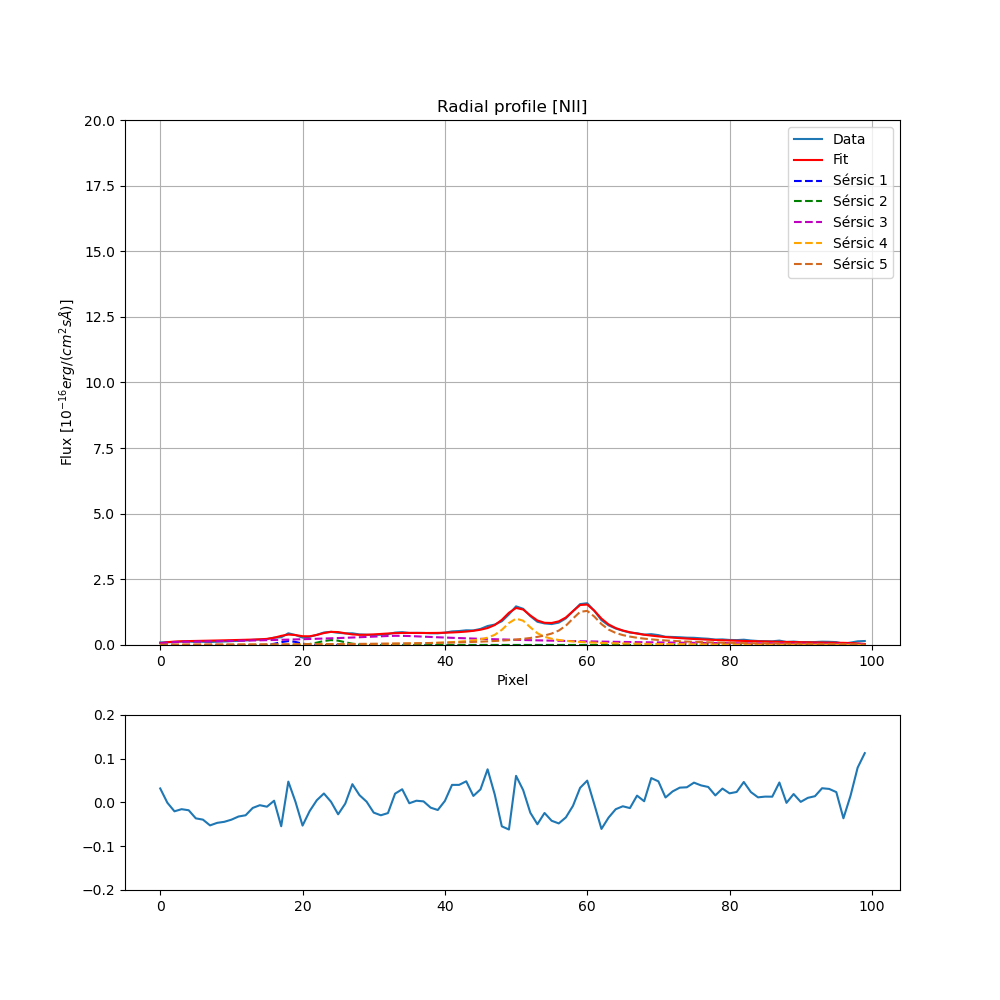

In [49]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [50]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2164, r_e=0.2756, n=1.4383, x_0=18.0614
Sérsic 2: I_e=0.1396, r_e=1.3544, n=0.5242, x_0=24.1067
Sérsic 3: I_e=0.0623, r_e=49.8583, n=1.0467, x_0=33.4414
Sérsic 4: I_e=0.0112, r_e=40.2167, n=3.3062, x_0=50.1804
Sérsic 5: I_e=0.0192, r_e=49.7042, n=2.9070, x_0=59.6129
[6.53364793e+01 1.04727850e+01 4.53772123e+02 4.09001388e-01
 5.67575129e-01 1.63332886e+00 3.43975440e+00 3.39221235e-01
 4.44975462e-02 3.21956823e+01 3.66701362e-01 1.51732285e+00
 8.20803855e-02 2.51960303e+02 5.55621750e+00 8.56226846e-02
 6.36087369e-02 1.44333830e+02 2.58452924e+00 1.21060744e-03]
0.4547860225358857


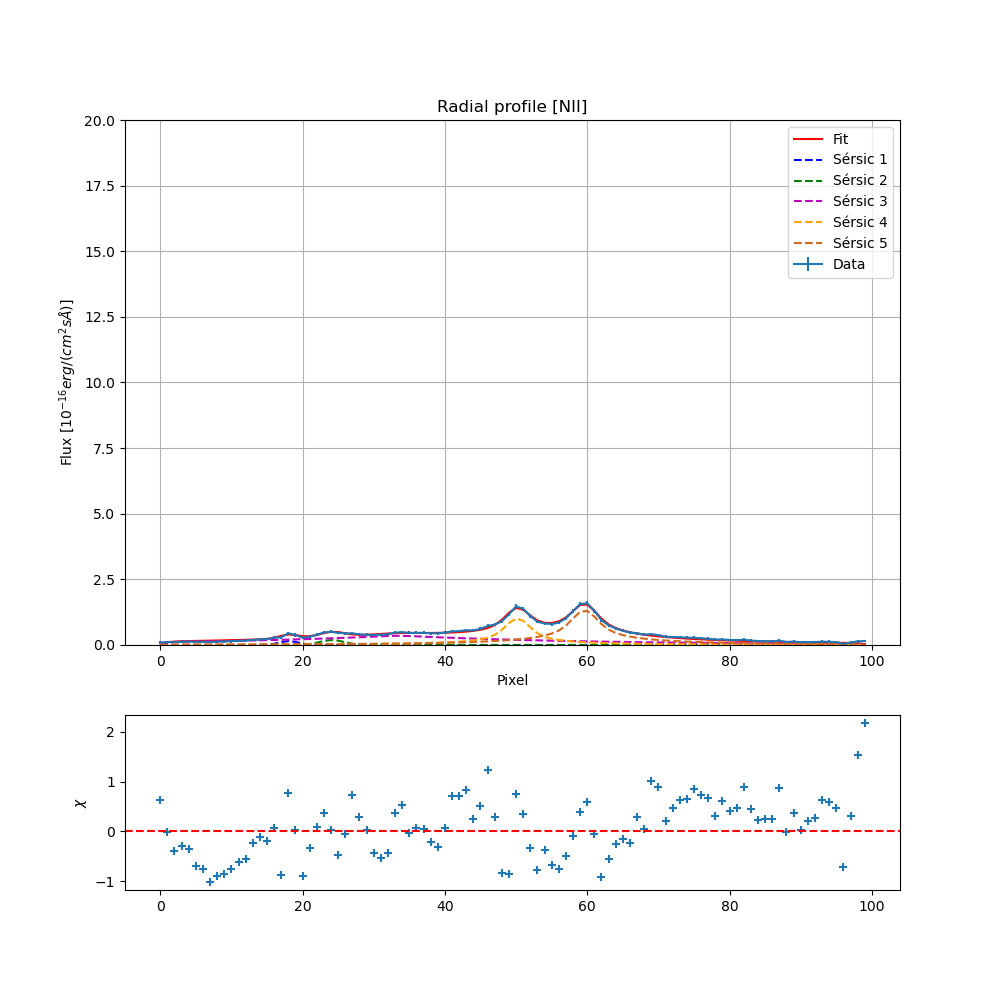

In [51]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

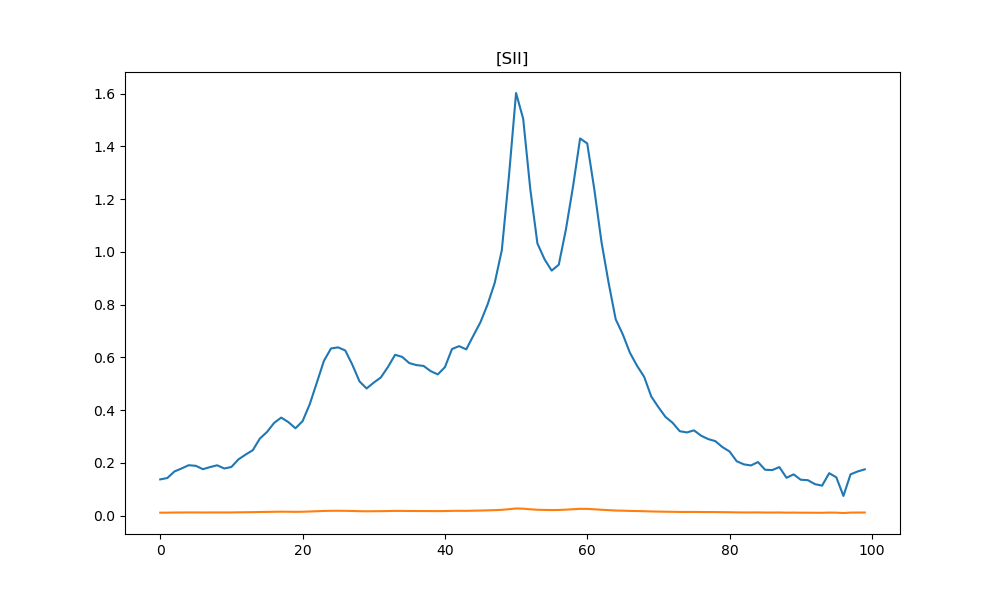

In [64]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [73]:
# Bounds:
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 0.15),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 12296.019032663291
differential_evolution step 2: f(x)= 12296.019032663291
differential_evolution step 3: f(x)= 11694.009372907323
differential_evolution step 4: f(x)= 3601.7991470216953
differential_evolution step 5: f(x)= 1720.8052996954377
differential_evolution step 6: f(x)= 1720.8052996954377
differential_evolution step 7: f(x)= 1629.8352079883782
differential_evolution step 8: f(x)= 1629.8352079883782
differential_evolution step 9: f(x)= 1629.8352079883782
differential_evolution step 10: f(x)= 363.8234494050229
differential_evolution step 11: f(x)= 363.8234494050229
differential_evolution step 12: f(x)= 363.8234494050229
differential_evolution step 13: f(x)= 363.8234494050229
differential_evolution step 14: f(x)= 363.8234494050229
differential_evolution step 15: f(x)= 363.8234494050229
differential_evolution step 16: f(x)= 363.8234494050229
differential_evolution step 17: f(x)= 168.74190578285115
differential_evolution step 18: f(x)= 168.74190

Sérsic 1: I_e=0.0036, r_e=0.8807, n=6.9371, x_0=15.8900
Sérsic 2: I_e=0.1270, r_e=2.1881, n=0.7003, x_0=24.3158
Sérsic 3: I_e=0.0698, r_e=49.4822, n=1.1177, x_0=33.3346
Sérsic 4: I_e=0.0142, r_e=30.7115, n=3.1802, x_0=50.2551
Sérsic 5: I_e=0.0359, r_e=49.2717, n=2.2148, x_0=59.6869


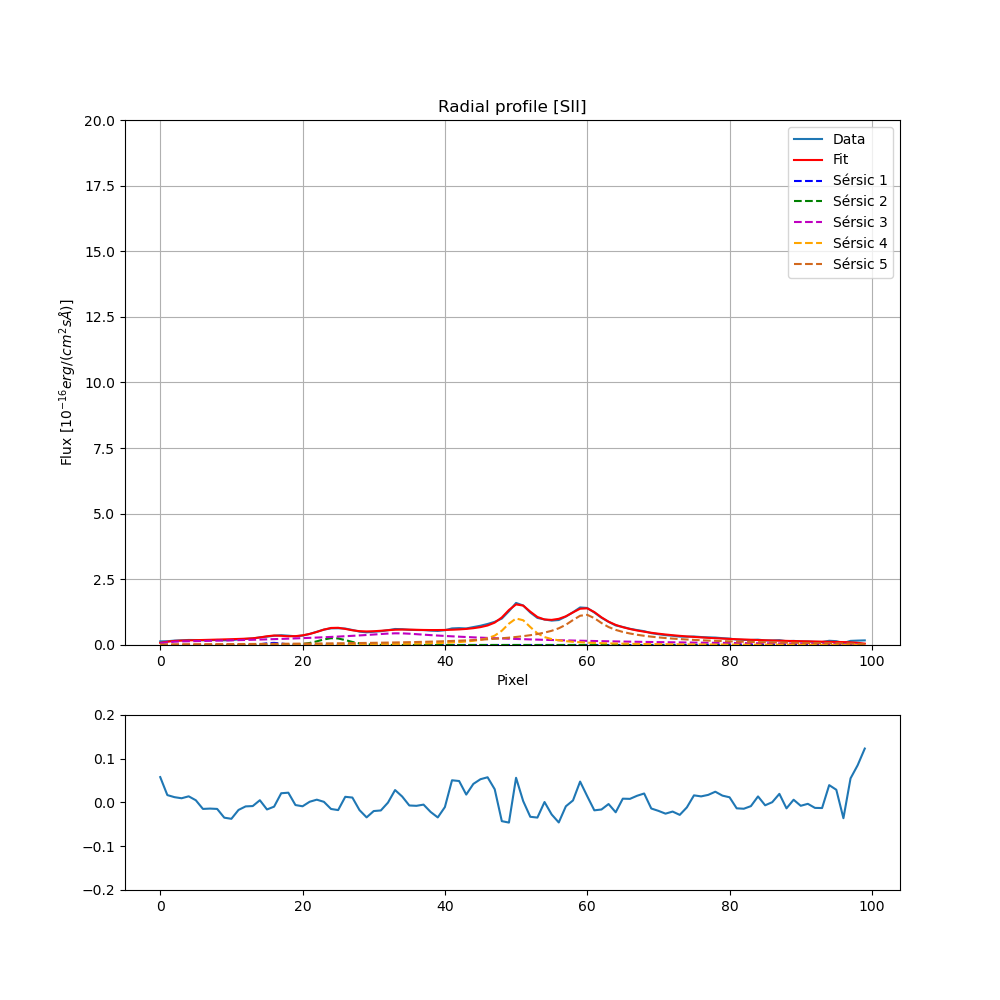

In [74]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [75]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0036, r_e=0.8806, n=6.9370, x_0=15.8899
Sérsic 2: I_e=0.1248, r_e=2.1786, n=0.6961, x_0=24.3143
Sérsic 3: I_e=0.0706, r_e=49.4827, n=1.1082, x_0=33.3361
Sérsic 4: I_e=0.0149, r_e=30.7297, n=3.1128, x_0=50.2551
Sérsic 5: I_e=0.0354, r_e=49.2724, n=2.2177, x_0=59.7093
[3.05975339e+00 3.68951062e+02 1.55130589e+03 6.83200289e-01
 1.36005181e-01 1.32651238e+00 8.63182864e-01 2.29320269e-01
 5.85026282e-02 3.02539309e+01 3.82837173e-01 1.09998921e+00
 2.12325755e-01 3.52960355e+02 1.17461337e+01 3.94032185e-03
 3.34775145e-02 6.70503738e+01 6.13730840e-01 1.06102195e-01]
0.3116254791316505


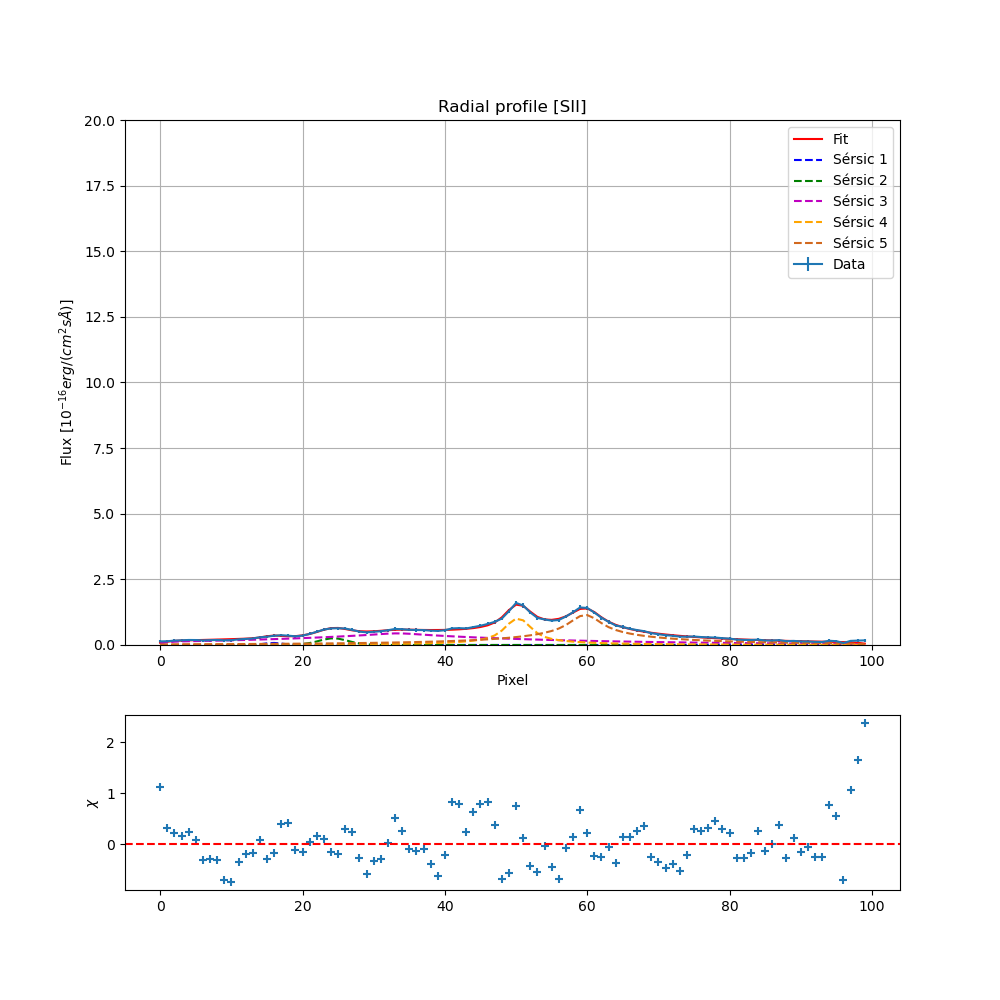

In [76]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

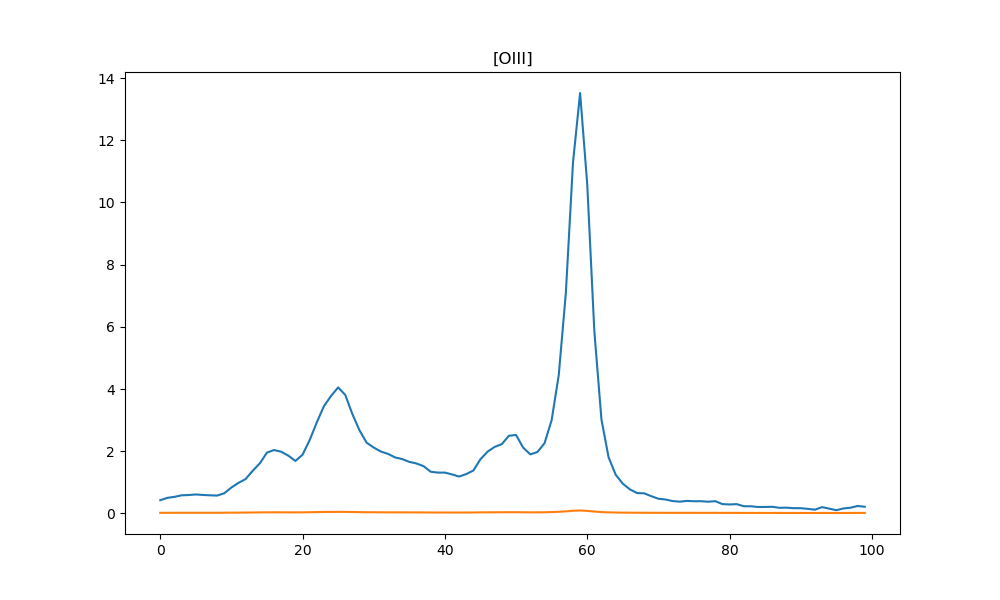

In [77]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [35]:
# Bounds:
bounds =[
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.8, x_0_HA[0]+1.8),   # x_0: circa la posizione di Halpha

    (0, 0.15),
    (0, 30),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 30),
    (0.1, 10),
    (x_0_HA[2]-1.2, x_0_HA[2]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.8, x_0_HA[3]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.8, x_0_HA[4]+1.8)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 102416.47387458401
differential_evolution step 2: f(x)= 73168.66321332184
differential_evolution step 3: f(x)= 19649.136778103377
differential_evolution step 4: f(x)= 19649.136778103377
differential_evolution step 5: f(x)= 3243.849401796697
differential_evolution step 6: f(x)= 3243.849401796697
differential_evolution step 7: f(x)= 3243.849401796697
differential_evolution step 8: f(x)= 3243.849401796697
differential_evolution step 9: f(x)= 3243.849401796697
differential_evolution step 10: f(x)= 3243.849401796697
differential_evolution step 11: f(x)= 1031.9081904394213
differential_evolution step 12: f(x)= 1031.9081904394213
differential_evolution step 13: f(x)= 1031.9081904394213
differential_evolution step 14: f(x)= 971.6138926758034
differential_evolution step 15: f(x)= 971.6138926758034
differential_evolution step 16: f(x)= 409.4561280989239
differential_evolution step 17: f(x)= 409.4561280989239
differential_evolution step 18: f(x)= 409.456128098

Sérsic 1: I_e=0.0550, r_e=46.1569, n=2.0867, x_0=15.7202
Sérsic 2: I_e=0.1500, r_e=16.2866, n=2.2527, x_0=24.5062
Sérsic 3: I_e=0.5635, r_e=4.4201, n=0.1250, x_0=31.3288
Sérsic 4: I_e=0.5529, r_e=18.0949, n=0.8900, x_0=51.6265
Sérsic 5: I_e=13.5289, r_e=0.6631, n=0.7221, x_0=58.8982


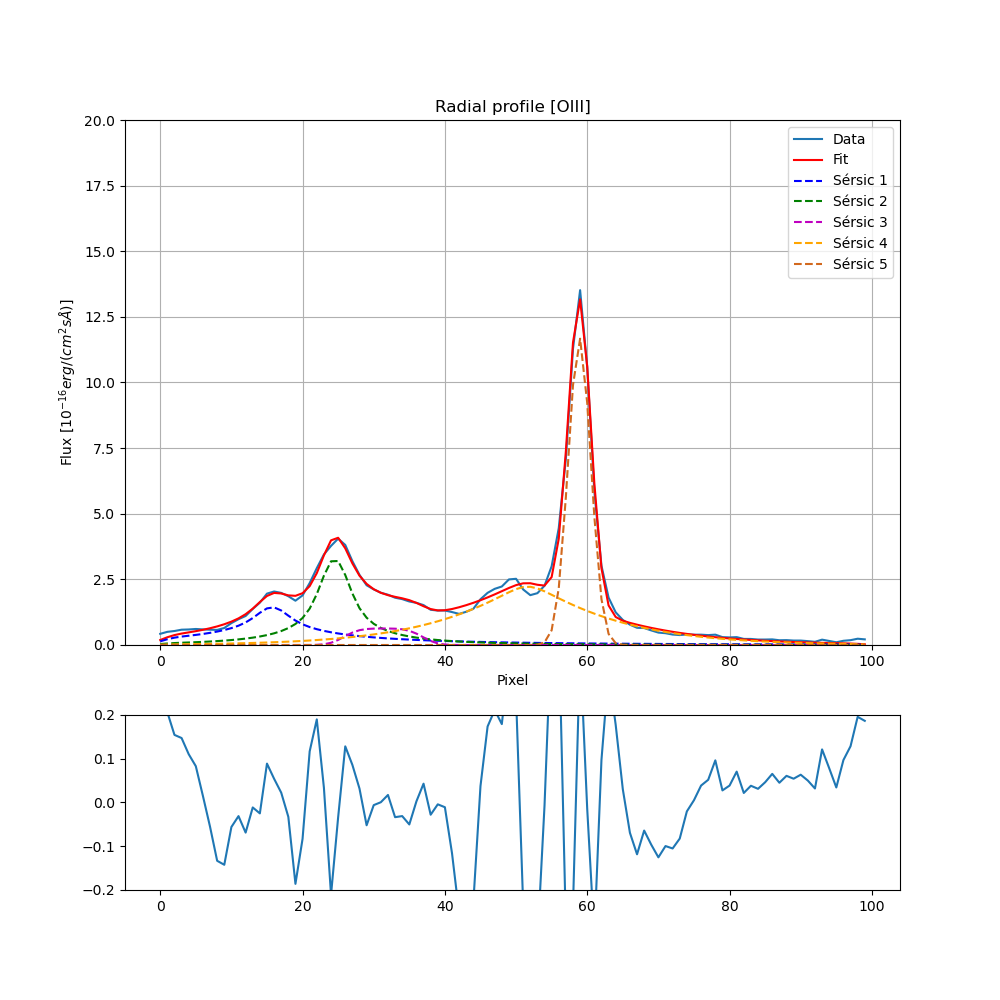

In [36]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [37]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0417, r_e=49.9985, n=2.2611, x_0=15.8192
Sérsic 2: I_e=0.1492, r_e=14.7973, n=2.2578, x_0=24.4547
Sérsic 3: I_e=0.5903, r_e=4.7751, n=0.2199, x_0=31.2954
Sérsic 4: I_e=0.1271, r_e=45.0005, n=1.7677, x_0=49.0447
Sérsic 5: I_e=0.7788, r_e=3.8036, n=2.9366, x_0=58.7963
[7.21906475e-02 1.17014352e+02 1.33989091e+00 3.93075806e-01
 8.51624900e-01 7.67896867e+01 3.52887969e+00 3.85438631e-01
 2.42157433e-01 4.59457053e+00 3.44611620e-01 7.18111717e+00
 1.11282118e-01 2.81250991e+01 5.21612375e-01 2.85022674e-01
 6.56337432e-01 1.86456475e+00 1.68632320e+00 3.57441940e-02]
1.5458385726377757


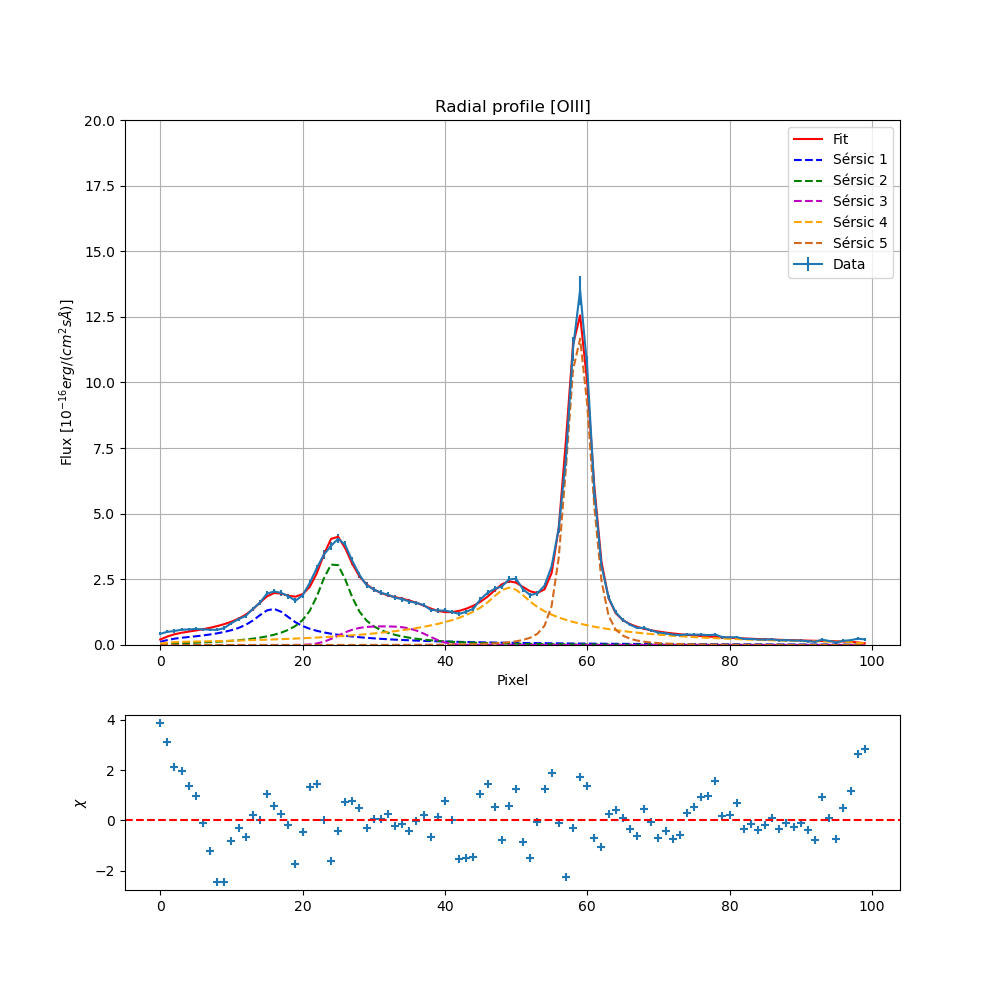

In [38]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [78]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

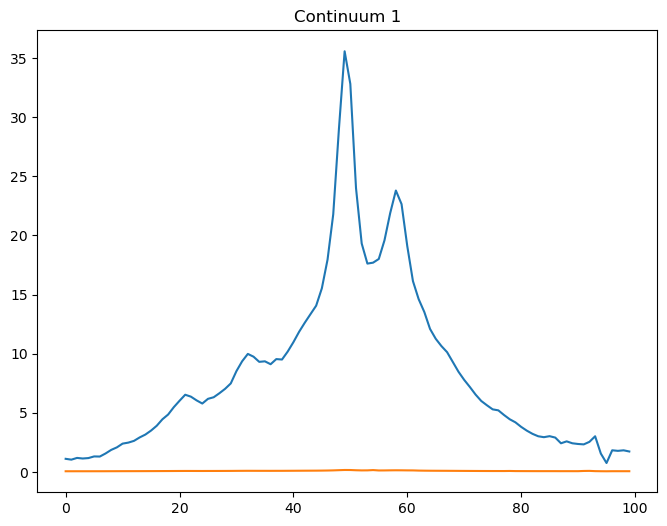

In [11]:
mask_continuum_1 = (wv > 4560)*(wv < 4860)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 151404.69165259265
differential_evolution step 2: f(x)= 151404.69165259265
differential_evolution step 3: f(x)= 59076.46763902683
differential_evolution step 4: f(x)= 37424.195980507444
differential_evolution step 5: f(x)= 37424.195980507444
differential_evolution step 6: f(x)= 11775.401399690929
differential_evolution step 7: f(x)= 9868.523773545085
differential_evolution step 8: f(x)= 6967.429064050416
differential_evolution step 9: f(x)= 6967.429064050416
differential_evolution step 10: f(x)= 4325.223297572592
differential_evolution step 11: f(x)= 4325.223297572592
differential_evolution step 12: f(x)= 4325.223297572592
differential_evolution step 13: f(x)= 3706.552381115088
differential_evolution step 14: f(x)= 1563.6009680659051
differential_evolution step 15: f(x)= 1563.6009680659051
differential_evolution step 16: f(x)= 1563.6009680659051
differential_evolution step 17: f(x)= 1563.6009680659051
differential_evolution step 18: f(x)= 1563.60096

In [13]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=0.1447, r_e=23.9645, n=1.2256, x_0=16.6192
Sérsic 2: I_e=1.1123, r_e=6.7656, n=0.8762, x_0=21.8370
Sérsic 3: I_e=4.7572, r_e=8.1217, n=0.1177, x_0=37.8968
Sérsic 4: I_e=0.9484, r_e=5.8866, n=3.1832, x_0=49.1658
Sérsic 5: I_e=1.4751, r_e=43.0154, n=1.6812, x_0=57.9295


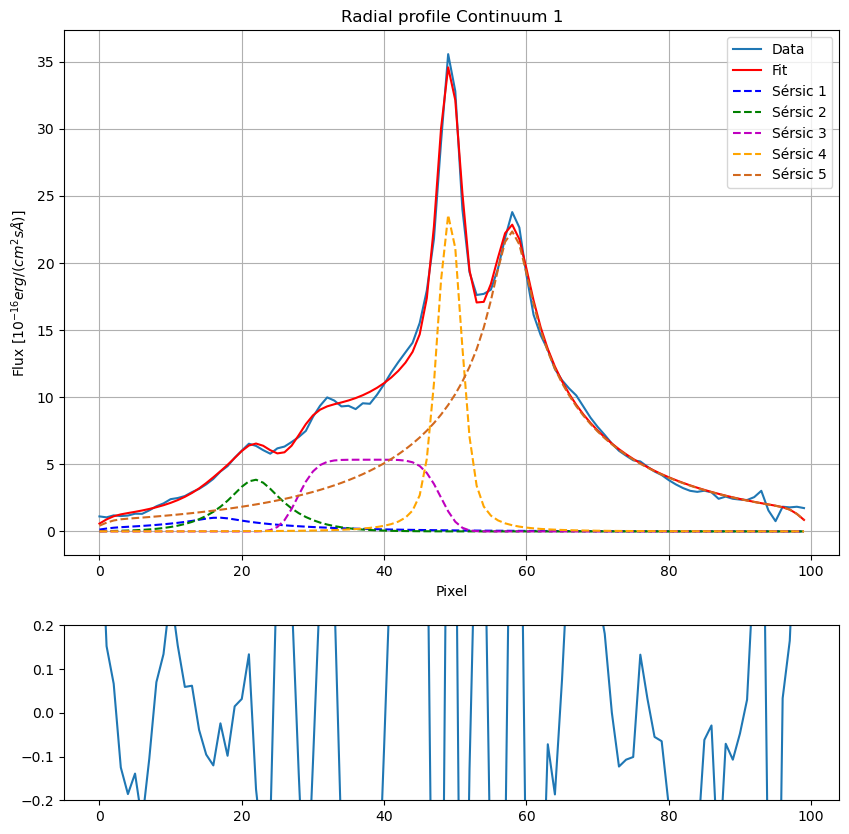

In [14]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [15]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1405, r_e=25.5903, n=0.9638, x_0=16.4719
Sérsic 2: I_e=1.1755, r_e=7.8146, n=0.8393, x_0=21.6155
Sérsic 3: I_e=4.5925, r_e=7.8670, n=0.1343, x_0=37.8715
Sérsic 4: I_e=0.9156, r_e=7.5423, n=2.8875, x_0=49.1658
Sérsic 5: I_e=1.5020, r_e=41.0963, n=1.6638, x_0=58.0498
[5.74418331e+00 7.74729955e+02 1.46945030e+01 2.94695977e+01
 4.31616996e+00 5.33277767e+01 2.78517748e+00 2.77487699e+00
 8.00421284e+00 4.41620755e+00 2.05192959e-01 3.57860085e+00
 3.99943992e+01 2.16189646e+02 5.08294222e+01 2.51104682e-02
 1.64912308e+00 1.10779694e+01 3.99816995e-01 6.19444034e-01]
5.544371562049148


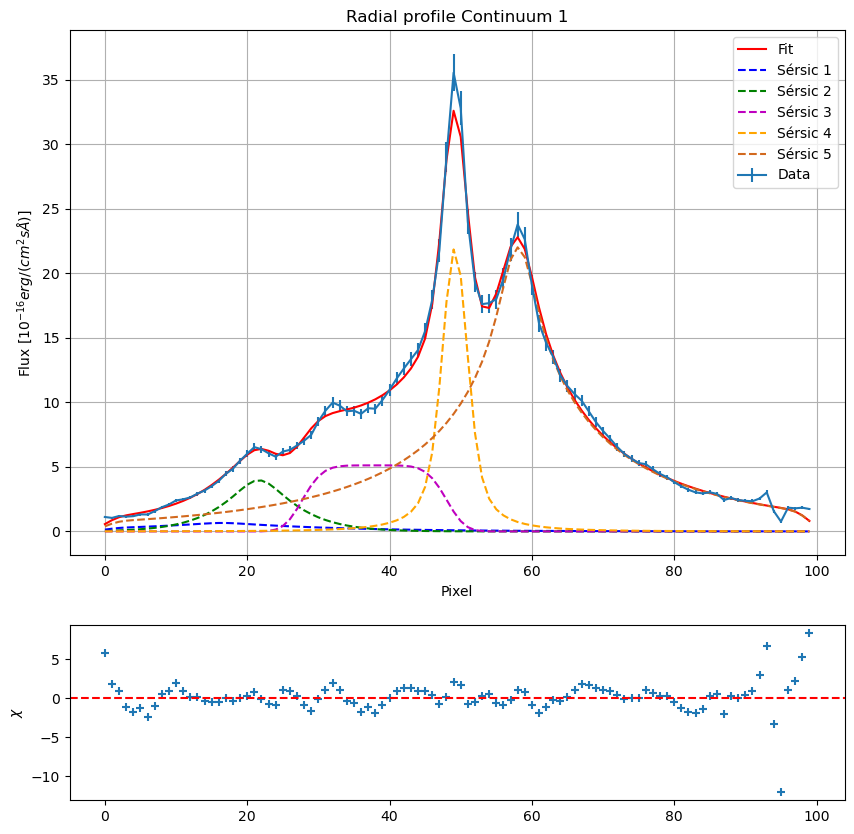

In [16]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

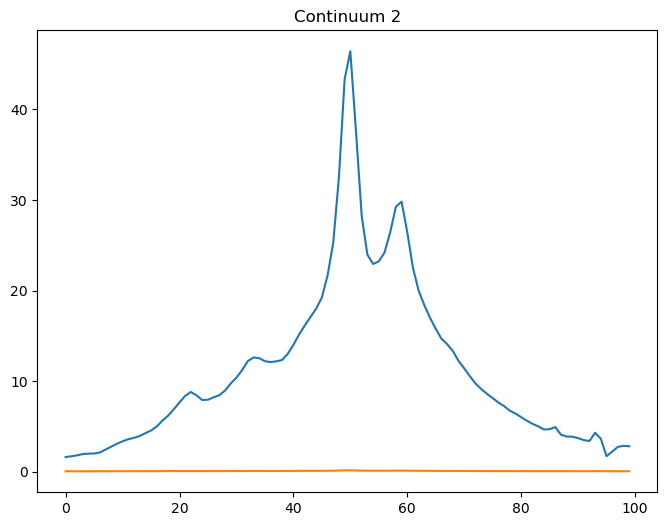

In [17]:
mask_continuum_2 = (wv > 5100)*(wv < 5550)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [18]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 235375.49924071244
differential_evolution step 2: f(x)= 163375.36219646895
differential_evolution step 3: f(x)= 163375.36219646895
differential_evolution step 4: f(x)= 159347.8288471132
differential_evolution step 5: f(x)= 113231.80050204034
differential_evolution step 6: f(x)= 12701.411180822915
differential_evolution step 7: f(x)= 7065.220014846921
differential_evolution step 8: f(x)= 7065.220014846921
differential_evolution step 9: f(x)= 7065.220014846921
differential_evolution step 10: f(x)= 7065.220014846921
differential_evolution step 11: f(x)= 7065.220014846921
differential_evolution step 12: f(x)= 7065.220014846921
differential_evolution step 13: f(x)= 7065.220014846921
differential_evolution step 14: f(x)= 6613.30381570727
differential_evolution step 15: f(x)= 6613.30381570727
differential_evolution step 16: f(x)= 4060.443932264724
differential_evolution step 17: f(x)= 2883.1888974565013
differential_evolution step 18: f(x)= 2883.1888974565

Sérsic 1: I_e=0.5354, r_e=7.7188, n=1.4633, x_0=19.9989
Sérsic 2: I_e=1.0258, r_e=18.8584, n=0.1019, x_0=27.5110
Sérsic 3: I_e=4.3758, r_e=9.1399, n=0.2339, x_0=37.8642
Sérsic 4: I_e=2.0994, r_e=4.4625, n=2.5008, x_0=49.6361
Sérsic 5: I_e=2.0050, r_e=47.8853, n=1.6082, x_0=58.4707


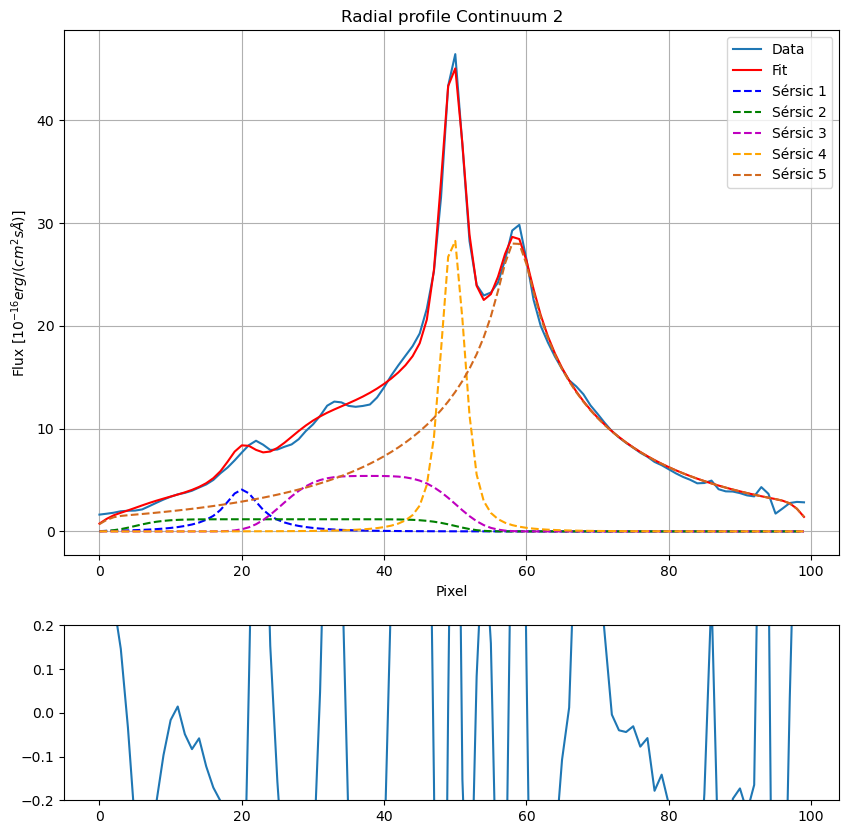

In [19]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [20]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.5016, r_e=10.5320, n=1.3245, x_0=19.9999
Sérsic 2: I_e=0.6687, r_e=20.2474, n=0.5000, x_0=27.4594
Sérsic 3: I_e=3.7783, r_e=9.2116, n=0.3093, x_0=37.8918
Sérsic 4: I_e=1.5249, r_e=7.0016, n=2.5358, x_0=49.5619
Sérsic 5: I_e=2.1156, r_e=44.1601, n=1.5520, x_0=58.6240
[3.13880236e+00 1.45327519e+02 5.03444814e+00 1.13723579e+00
 9.41962721e+00 6.78269349e+01 3.08207312e+00 1.56671040e+02
 8.65139218e+00 1.63987236e+01 7.77230686e-01 2.89858406e+01
 4.42704065e+01 1.35050120e+02 3.46573779e+01 8.70465562e-02
 1.56419040e+00 1.75154440e+01 2.94287176e-01 6.65861540e-01]
6.1593994005762855


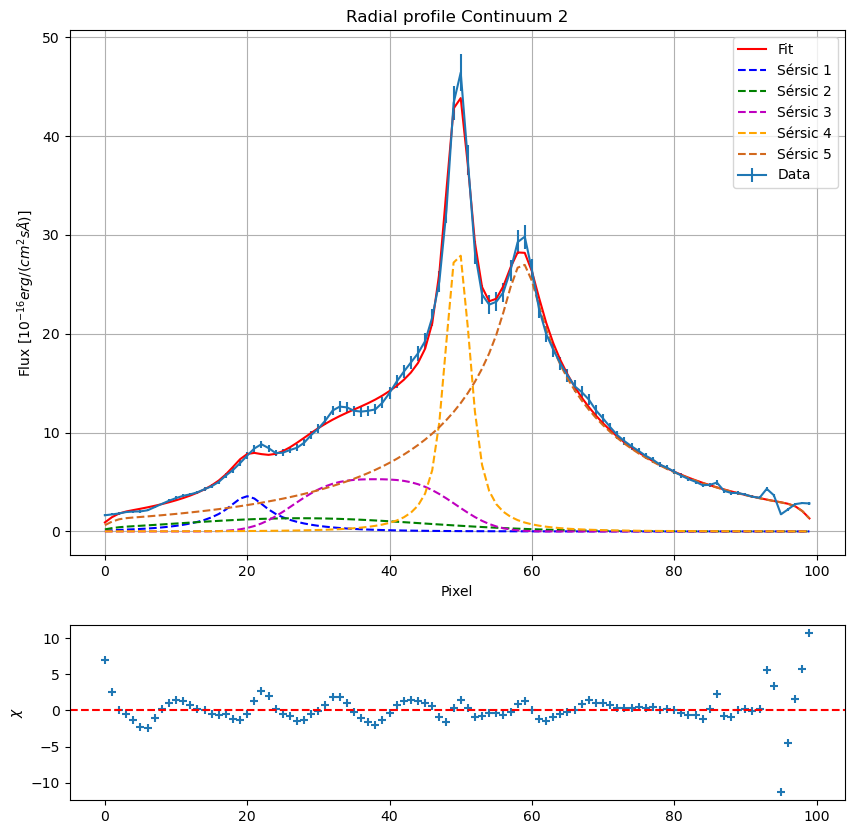

In [21]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

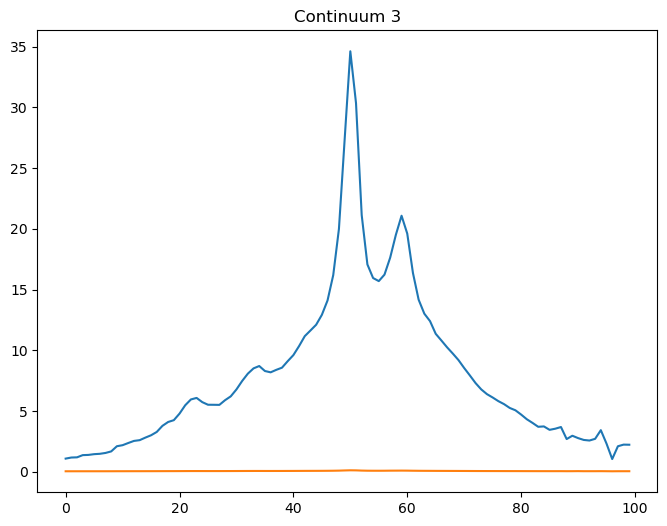

In [22]:
mask_continuum_3 = (wv > 5920)*(wv < 6290)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [23]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 17466.441038414116
differential_evolution step 2: f(x)= 17466.441038414116
differential_evolution step 3: f(x)= 17466.441038414116
differential_evolution step 4: f(x)= 17466.441038414116
differential_evolution step 5: f(x)= 17466.441038414116
differential_evolution step 6: f(x)= 17466.441038414116
differential_evolution step 7: f(x)= 17466.441038414116
differential_evolution step 8: f(x)= 17466.441038414116
differential_evolution step 9: f(x)= 17466.441038414116
differential_evolution step 10: f(x)= 17466.441038414116
differential_evolution step 11: f(x)= 17466.441038414116
differential_evolution step 12: f(x)= 17466.441038414116
differential_evolution step 13: f(x)= 17466.441038414116
differential_evolution step 14: f(x)= 17466.441038414116
differential_evolution step 15: f(x)= 17466.441038414116
differential_evolution step 16: f(x)= 8981.402888619366
differential_evolution step 17: f(x)= 2954.3903839936725
differential_evolution step 18: f(x)= 295

Sérsic 1: I_e=0.1395, r_e=16.4486, n=1.6799, x_0=16.6389
Sérsic 2: I_e=2.4733, r_e=2.6090, n=0.2377, x_0=23.0506
Sérsic 3: I_e=3.7140, r_e=8.5281, n=0.1000, x_0=37.9791
Sérsic 4: I_e=0.9222, r_e=5.5683, n=3.1558, x_0=50.0570
Sérsic 5: I_e=1.4102, r_e=49.9702, n=1.5914, x_0=58.7915


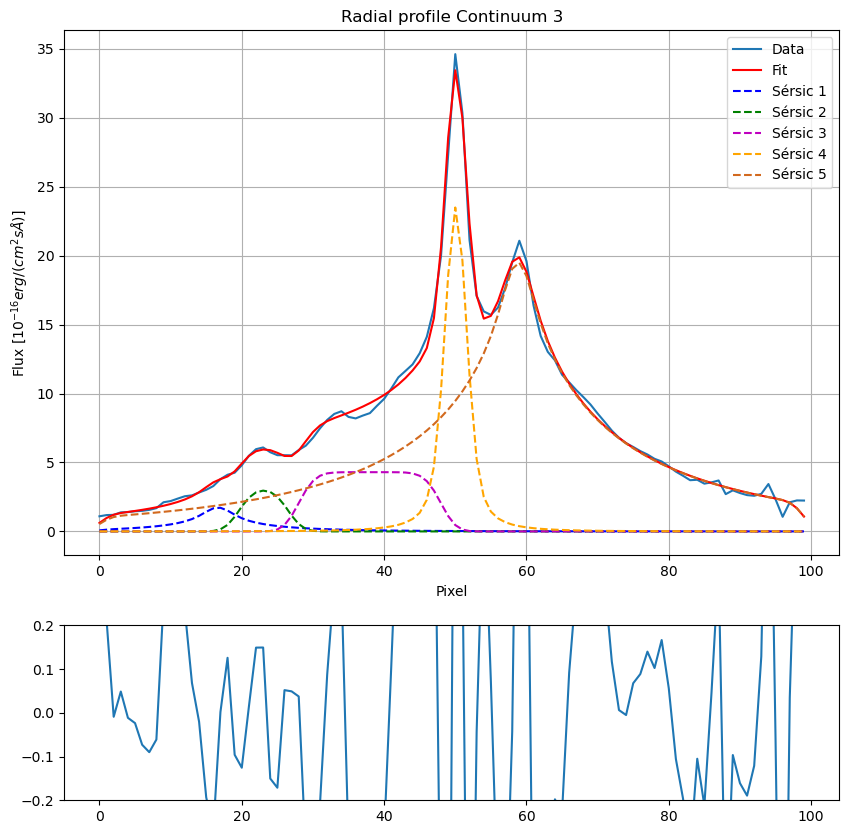

In [24]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [25]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7904\2443474052.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7904\2443474052.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1784, r_e=23.6877, n=1.4630, x_0=17.4085
Sérsic 2: I_e=2.0341, r_e=2.5217, n=0.3247, x_0=23.1563
Sérsic 3: I_e=3.5401, r_e=8.4478, n=0.1137, x_0=38.4118
Sérsic 4: I_e=0.6145, r_e=7.9276, n=3.3073, x_0=50.0570
Sérsic 5: I_e=1.6777, r_e=43.0469, n=1.4697, x_0=58.7883
[3.63121626e-01 3.63049294e+01 1.34278661e+00 9.19389297e+00
 4.51627552e+00 6.71954714e+00 1.84077692e+00 1.11224044e+00
 1.87829779e+00 5.29747593e+00 2.87235673e-01 1.69501352e+00
 1.45970233e+01 1.16449404e+02 3.31547525e+01 3.62136452e-03
 5.20543077e-01 6.80524531e+00 1.47638881e-01 5.15739204e-01]
5.942163099171489


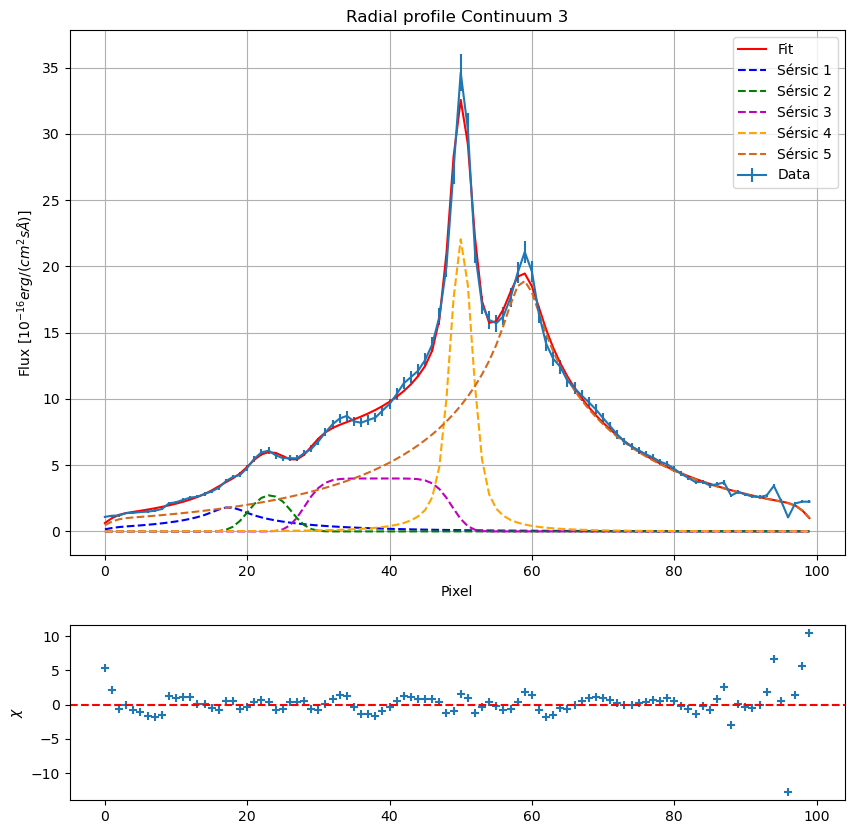

In [26]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [27]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)